# Truncation Blind Spot Analysis
This notebook generates:
1. **Motivation Figure**: Token ranking curves comparing two models on the same text
2. **Within-Family Top-k and Top-p Overlap**: Heatmaps for GPT-2 and Qwen2 families


## Setup

In [ ]:
!pip install transformers accelerate torch datasets matplotlib seaborn numpy pandas --quiet

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoModelForCausalLM, AutoTokenizer
from collections import defaultdict
import pandas as pd
from typing import List, Dict, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# Publication-quality figure settings
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: NVIDIA A100-SXM4-40GB
Memory: 42.5 GB


## Helper Functions

In [ ]:
def get_token_ranks(model, tokenizer, text: str, prompt: str = "") -> Tuple[List[int], List[str], List[float]]:
    """
    Compute the rank of each token in the text according to the model's predictions.

    Returns:
        ranks: List of ranks (1-indexed, 1 = most probable)
        tokens: List of token strings
        probs: List of probabilities assigned to each token
    """
    full_text = prompt + text if prompt else text
    inputs = tokenizer(full_text, return_tensors="pt").to(device)
    input_ids = inputs["input_ids"][0]

    if prompt:
        prompt_ids = tokenizer(prompt, return_tensors="pt")["input_ids"][0]
        start_idx = len(prompt_ids)
    else:
        start_idx = 1

    ranks = []
    tokens = []
    probs = []

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits[0]

    for i in range(start_idx, len(input_ids)):
        position_logits = logits[i - 1]
        probabilities = torch.softmax(position_logits, dim=-1)
        actual_token_id = input_ids[i].item()
        actual_token_prob = probabilities[actual_token_id].item()
        rank = (probabilities > actual_token_prob).sum().item() + 1

        ranks.append(rank)
        tokens.append(tokenizer.decode([actual_token_id]))
        probs.append(actual_token_prob)

    return ranks, tokens, probs


def get_topk_set(model, tokenizer, text: str, k: int, prompt: str = "") -> List[set]:
    """
    Get the top-k token sets at each position for a given text.
    """
    full_text = prompt + text if prompt else text
    inputs = tokenizer(full_text, return_tensors="pt").to(device)
    input_ids = inputs["input_ids"][0]

    if prompt:
        prompt_ids = tokenizer(prompt, return_tensors="pt")["input_ids"][0]
        start_idx = len(prompt_ids)
    else:
        start_idx = 1

    topk_sets = []

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits[0]

    for i in range(start_idx, len(input_ids)):
        position_logits = logits[i - 1]
        topk_ids = torch.topk(position_logits, k).indices.cpu().tolist()
        topk_sets.append(set(topk_ids))

    return topk_sets


def get_topp_set(model, tokenizer, text: str, p: float, prompt: str = "") -> List[set]:
    """
    Get the nucleus (top-p) token sets at each position for a given text.

    The nucleus contains the smallest set of tokens whose cumulative probability >= p.
    """
    full_text = prompt + text if prompt else text
    inputs = tokenizer(full_text, return_tensors="pt").to(device)
    input_ids = inputs["input_ids"][0]

    if prompt:
        prompt_ids = tokenizer(prompt, return_tensors="pt")["input_ids"][0]
        start_idx = len(prompt_ids)
    else:
        start_idx = 1

    topp_sets = []

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits[0]

    for i in range(start_idx, len(input_ids)):
        position_logits = logits[i - 1]
        probabilities = torch.softmax(position_logits, dim=-1)

        # Sort by probability descending
        sorted_probs, sorted_indices = torch.sort(probabilities, descending=True)
        cumsum_probs = torch.cumsum(sorted_probs, dim=0)

        # Find cutoff index where cumsum >= p
        cutoff_idx = torch.searchsorted(cumsum_probs, p).item() + 1

        # Get the nucleus tokens
        nucleus_ids = sorted_indices[:cutoff_idx].cpu().tolist()
        topp_sets.append(set(nucleus_ids))

    return topp_sets


def compute_overlap_coefficient(sets_a: List[set], sets_b: List[set]) -> float:
    """
    Compute the average Jaccard overlap between two lists of sets.
    """
    assert len(sets_a) == len(sets_b), "Lists must have same length"

    overlaps = []
    for set_a, set_b in zip(sets_a, sets_b):
        intersection = len(set_a & set_b)
        union = len(set_a | set_b)
        if union > 0:
            overlaps.append(intersection / union)

    return np.mean(overlaps)


def compute_human_token_in_topk(ranks: List[int], k: int) -> float:
    """
    Compute the proportion of human tokens that fall within top-k.
    """
    in_topk = sum(1 for r in ranks if r <= k)
    return in_topk / len(ranks)

## Sample Text

**Replace with actual sample from your dataset!**

In [ ]:
# Use a SINGLE text for the motivation figure (same text, different models)
MOTIVATION_TEXT = """On 3 January 2026, the United States military invaded Venezuela, capturing and extrajudicially renditioning Venezuelan president Nicolás Maduro and his wife Cilia Flores. The attack, codenamed Absolute Resolve, began around 02:00 local time as explosions were observed. More than 150 United States Armed Forces airplanes bombed infrastructure across northern Venezuela in support of an apprehension force that landed in the capital city of Caracas. Venezuelan vice president Delcy Rodríguez denounced the capture as a kidnapping. According to Venezuelan and Cuban officials, more than 80 people were killed in the attack, including 32 Cuban military and intelligence members. Maduro and Flores were flown to New York City by US forces. US attorney general Pam Bondi announced that Maduro and Flores had been indicted in the US Southern District of New York on several charges related to narcoterrorism, superseding a 2020 indictment based on similar charges. Maduro is to appear in a Manhattan federal court on 5 January 2026."""

# Texts for overlap analysis
SAMPLE_TEXTS = {
    "wikinews": MOTIVATION_TEXT,

    "wikipedia": """The African elephant is the largest living terrestrial animal, with bulls reaching a shoulder height of up to 4 meters and weighing approximately 6 tonnes. These magnificent creatures are distinguished by their large ears, which serve both thermoregulatory and communicative functions. Unlike their Asian counterparts, African elephants possess two finger-like projections at the tip of their trunk, enabling remarkable dexterity in manipulating objects. Their social structure centers around matriarchal family units, typically led by the oldest female who guides the herd to water sources and feeding grounds based on accumulated knowledge passed down through generations.""",

    "bookcorpus": """The old lighthouse keeper had seen many storms in his forty years on the rocky peninsula, but nothing quite like this. The waves crashed against the cliffs with a fury that seemed almost personal, as if the sea itself harbored some ancient grudge against the land. He climbed the spiral staircase one more time, his knees protesting with each step, to ensure the great lamp was burning bright. Somewhere out there, he knew, a ship was fighting for survival, its crew placing their faith in this single beam of light cutting through the darkness."""
}

# Text source for the motivation figure (for labeling)
MOTIVATION_TEXT_SOURCE = "WikiNews"

---
# Part 1: Motivation Figure

Shows token ranking curves for the **same text** under **two different models**:
- GPT2-XL (historical baseline, in paper)
- Qwen2-7B (modern model, in paper)

This illustrates how human-chosen tokens often receive high ranks regardless of model.

In [ ]:
def create_motivation_figure_two_models(
    text: str,
    text_source: str,
    model_configs: List[Tuple[str, str]],  # List of (display_name, model_path)
    k_values: List[int] = [5, 10, 20, 50],
    save_path: str = "motivation_figure.pdf"
):
    """
    Create motivation figure showing token ranks for the same text under multiple models.

    Args:
        text: The human-written text to analyze
        text_source: Label for the text source (e.g., "WikiNews")
        model_configs: List of (display_name, huggingface_path) tuples
        k_values: List of k values to show as reference lines
        save_path: Where to save the figure
    """

    n_models = len(model_configs)
    fig, axes = plt.subplots(n_models, 1, figsize=(12, 4*n_models), sharex=True)

    if n_models == 1:
        axes = [axes]

    # Colors for different k thresholds
    k_colors = {5: '#3498DB', 10: '#2ECC71', 20: '#F39C12', 50: '#9B59B6'}
    k_styles = {5: ':', 10: '--', 20: '-.', 50: '-'}

    all_results = {}

    for idx, (display_name, model_path) in enumerate(model_configs):
        ax = axes[idx]

        print(f"\n{'='*50}")
        print(f"Processing: {display_name}")
        print(f"{'='*50}")

        # Load model
        tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token

        model = AutoModelForCausalLM.from_pretrained(
            model_path,
            torch_dtype=torch.float16,
            device_map="auto",
            trust_remote_code=True
        )
        model.eval()

        # Get ranks
        ranks, tokens, probs = get_token_ranks(model, tokenizer, text)
        all_results[display_name] = {'ranks': ranks, 'tokens': tokens, 'probs': probs}

        print(f"Computed ranks for {len(ranks)} tokens")

        # Plot
        positions = range(len(ranks))

        # Color by whether in typical truncation range (use k=10 as example)
        colors = ['#2C3E50' if r <= 10 else '#E74C3C' for r in ranks]

        ax.scatter(positions, ranks, c=colors, s=20, alpha=0.7, zorder=3,
                   edgecolors='white', linewidth=0.3)
        ax.plot(positions, ranks, color='gray', alpha=0.15, linewidth=0.5, zorder=2)

        # Add k threshold lines
        for k in k_values:
            exclusion = 100 * (1 - compute_human_token_in_topk(ranks, k))
            ax.axhline(y=k, linestyle=k_styles[k], color=k_colors[k], alpha=0.8, linewidth=1.5,
                       label=f'k={k} ({exclusion:.1f}% excluded)')

        # Styling
        ax.set_yscale('log')
        ax.set_ylabel('Token Rank (log scale)', fontsize=11)
        ax.set_title(f'{display_name}', fontsize=12, fontweight='bold', loc='left')
        ax.set_ylim(0.8, max(ranks) * 2)
        ax.grid(True, alpha=0.3, which='both')
        ax.legend(loc='upper right', fontsize=8, title='Truncation Threshold')

        # Light shading for blind spot region
        ax.axhspan(50, max(ranks) * 2, alpha=0.05, color='#E74C3C', zorder=1)

        # Cleanup
        del model
        torch.cuda.empty_cache()

    axes[-1].set_xlabel('Token Position in Text', fontsize=11)

    # Overall title
    fig.suptitle(f'Token Ranks for Human-Written Text ({text_source})\n'
                 f'Same text analyzed by different language models',
                 fontsize=13, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.savefig(save_path.replace('.pdf', '.png'), bbox_inches='tight')
    print(f"\nSaved: {save_path}")
    plt.show()

    # Print comparative statistics
    print("\n" + "="*70)
    print("COMPARATIVE STATISTICS")
    print("="*70)
    print(f"{'Model':<25} {'Median':>8} {'Mean':>8} {'Max':>8}  ", end="")
    for k in k_values:
        print(f"k={k}:excl", end="  ")
    print()
    print("-"*70)

    for name, data in all_results.items():
        ranks = data['ranks']
        print(f"{name:<25} {np.median(ranks):>8.1f} {np.mean(ranks):>8.1f} {max(ranks):>8d}  ", end="")
        for k in k_values:
            excl = 100 * (1 - compute_human_token_in_topk(ranks, k))
            print(f"{excl:>7.1f}%", end="  ")
        print()

    return all_results


Processing: GPT2-XL (1.5B)
Computed ranks for 195 tokens

Processing: Qwen2-7B


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Computed ranks for 216 tokens

Saved: motivation_figure.pdf


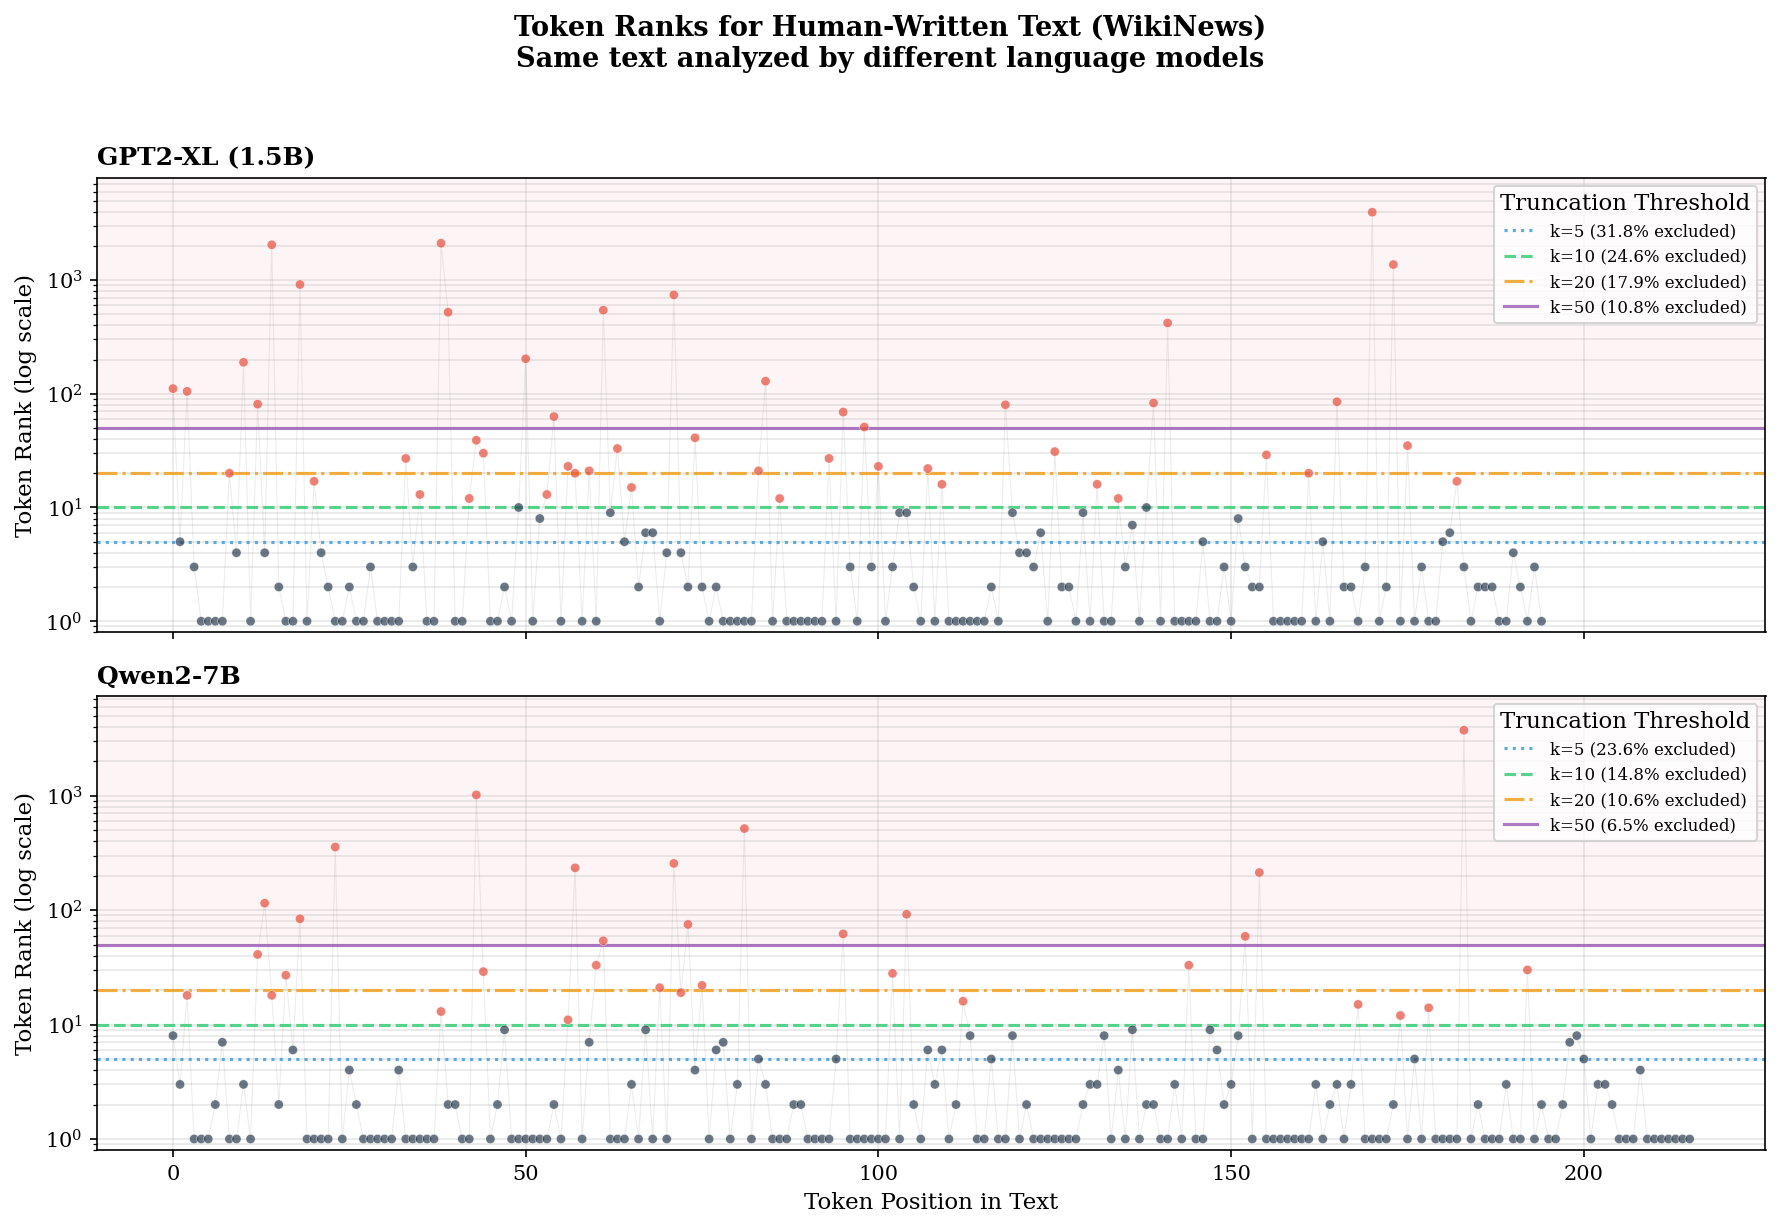


COMPARATIVE STATISTICS
Model                       Median     Mean      Max  k=5:excl  k=10:excl  k=20:excl  k=50:excl  
----------------------------------------------------------------------
GPT2-XL (1.5B)                 2.0     75.8     3947     31.8%     24.6%     17.9%     10.8%  
Qwen2-7B                       1.0     35.5     3732     23.6%     14.8%     10.6%      6.5%  


In [ ]:
# Models to compare
MOTIVATION_MODELS = [
    ("GPT2-XL (1.5B)", "gpt2-xl"),
    ("Qwen2-7B", "Qwen/Qwen2-7B")
]

# Run motivation figure
motivation_results = create_motivation_figure_two_models(
    text=MOTIVATION_TEXT,
    text_source=MOTIVATION_TEXT_SOURCE,
    model_configs=MOTIVATION_MODELS,
    k_values=[5, 10, 20, 50],
    save_path="motivation_figure.pdf"
)

---
# Part 2: Within-Family Overlap Analysis

Computes both **top-k** and **top-p (nucleus)** overlap within model families.

In [ ]:
# Model families - ORDERED BY SIZE (smallest to largest)

GPT2_FAMILY = {
    "GPT2-S\n(124M)": "gpt2",
    "GPT2-M\n(355M)": "gpt2-medium",
    "GPT2-L\n(774M)": "gpt2-large",
    "GPT2-XL\n(1.5B)": "gpt2-xl"
}


QWEN2_FAMILY = {
    "Qwen2\n(0.5B)": "Qwen/Qwen2-0.5B",
    "Qwen2\n(1.5B)": "Qwen/Qwen2-1.5B",
    "Qwen2\n(7B)": "Qwen/Qwen2-7B"
}

In [ ]:
def compute_family_overlap_topk_and_topp(
    family: Dict[str, str],
    texts: Dict[str, str],
    k_values: List[int] = [10, 20, 50],
    p_values: List[float] = [0.6, 0.8, 0.95],
    family_name: str = "Family"
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Compute pairwise top-k AND top-p overlap within a model family.

    Returns:
        df_topk: DataFrame with top-k overlap results
        df_topp: DataFrame with top-p overlap results
    """
    model_names = list(family.keys())

    results_topk = []
    results_topp = []

    # Store all sets
    all_topk_sets = {}  # {model: {text: {k: [sets]}}}
    all_topp_sets = {}  # {model: {text: {p: [sets]}}}

    # Load each model and compute sets
    for name, path in family.items():
        print(f"\n{'='*60}")
        print(f"Loading {name.replace(chr(10), ' ')}...")
        print(f"{'='*60}")

        tokenizer = AutoTokenizer.from_pretrained(path, trust_remote_code=True)
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token

        model = AutoModelForCausalLM.from_pretrained(
            path,
            torch_dtype=torch.float16,
            device_map="auto",
            trust_remote_code=True
        )
        model.eval()

        all_topk_sets[name] = {}
        all_topp_sets[name] = {}

        for text_key, text in texts.items():
            print(f"  Processing {text_key}...")
            all_topk_sets[name][text_key] = {}
            all_topp_sets[name][text_key] = {}

            # Compute top-k sets
            for k in k_values:
                topk_sets = get_topk_set(model, tokenizer, text, k)
                all_topk_sets[name][text_key][k] = topk_sets

            # Compute top-p sets
            for p in p_values:
                topp_sets = get_topp_set(model, tokenizer, text, p)
                all_topp_sets[name][text_key][p] = topp_sets

        del model
        torch.cuda.empty_cache()
        print(f"  Done. Memory cleared.")

    # Compute pairwise overlaps
    print(f"\n{'='*60}")
    print("Computing pairwise overlaps...")
    print(f"{'='*60}")

    for i, name_a in enumerate(model_names):
        for j, name_b in enumerate(model_names):
            if i >= j:
                continue

            print(f"  {name_a.replace(chr(10), ' ')} vs {name_b.replace(chr(10), ' ')}")

            for text_key in texts.keys():
                # Top-k overlaps
                for k in k_values:
                    sets_a = all_topk_sets[name_a][text_key][k]
                    sets_b = all_topk_sets[name_b][text_key][k]
                    min_len = min(len(sets_a), len(sets_b))
                    overlap = compute_overlap_coefficient(sets_a[:min_len], sets_b[:min_len])

                    results_topk.append({
                        'Model A': name_a,
                        'Model B': name_b,
                        'Text': text_key,
                        'k': k,
                        'Overlap': overlap
                    })

                # Top-p overlaps
                for p in p_values:
                    sets_a = all_topp_sets[name_a][text_key][p]
                    sets_b = all_topp_sets[name_b][text_key][p]
                    min_len = min(len(sets_a), len(sets_b))
                    overlap = compute_overlap_coefficient(sets_a[:min_len], sets_b[:min_len])

                    results_topp.append({
                        'Model A': name_a,
                        'Model B': name_b,
                        'Text': text_key,
                        'p': p,
                        'Overlap': overlap
                    })

    df_topk = pd.DataFrame(results_topk)
    df_topp = pd.DataFrame(results_topp)

    # Save
    prefix = family_name.lower().replace(' ', '_').replace('-', '')
    df_topk.to_csv(f"{prefix}_topk_overlap.csv", index=False)
    df_topp.to_csv(f"{prefix}_topp_overlap.csv", index=False)
    print(f"\nSaved: {prefix}_topk_overlap.csv, {prefix}_topp_overlap.csv")

    return df_topk, df_topp

In [ ]:
def plot_family_overlap_combined(
    df_topk: pd.DataFrame,
    df_topp: pd.DataFrame,
    family_name: str,
    save_path: str
):
    """
    Create combined heatmap figure with top-k on top row and top-p on bottom row.
    Models are ordered by size (as defined in the family dict).
    """
    k_values = sorted(df_topk['k'].unique())
    p_values = sorted(df_topp['p'].unique())

    n_cols = max(len(k_values), len(p_values))

    fig, axes = plt.subplots(2, n_cols, figsize=(4*n_cols, 8))

    # Get models in order (they should already be ordered in the dataframe)
    models_topk = list(dict.fromkeys(list(df_topk['Model A']) + list(df_topk['Model B'])))
    models_topp = list(dict.fromkeys(list(df_topp['Model A']) + list(df_topp['Model B'])))

    # Top row: top-k heatmaps
    for idx, k in enumerate(k_values):
        ax = axes[0, idx]
        df_k = df_topk[df_topk['k'] == k]

        # Create matrix (models already in size order)
        matrix = np.ones((len(models_topk), len(models_topk)))

        for _, row in df_k.iterrows():
            i = models_topk.index(row['Model A'])
            j = models_topk.index(row['Model B'])
            avg_overlap = df_k[
                (df_k['Model A'] == row['Model A']) &
                (df_k['Model B'] == row['Model B'])
            ]['Overlap'].mean()
            matrix[i, j] = avg_overlap
            matrix[j, i] = avg_overlap

        # Clean labels (remove newlines for axis)
        labels = [m.replace('\n', ' ') for m in models_topk]

        sns.heatmap(matrix, annot=True, fmt='.3f', cmap='Blues',
                   xticklabels=labels, yticklabels=labels,
                   ax=ax, vmin=0, vmax=1,
                   cbar_kws={'label': 'Jaccard'} if idx == len(k_values)-1 else {'label': ''},
                   annot_kws={'size': 9})

        ax.set_title(f'top-k (k={k})', fontsize=11, fontweight='bold')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

    # Hide extra columns in top row if fewer k values than p values
    for idx in range(len(k_values), n_cols):
        axes[0, idx].axis('off')

    # Bottom row: top-p heatmaps
    for idx, p in enumerate(p_values):
        ax = axes[1, idx]
        df_p = df_topp[df_topp['p'] == p]

        matrix = np.ones((len(models_topp), len(models_topp)))

        for _, row in df_p.iterrows():
            i = models_topp.index(row['Model A'])
            j = models_topp.index(row['Model B'])
            avg_overlap = df_p[
                (df_p['Model A'] == row['Model A']) &
                (df_p['Model B'] == row['Model B'])
            ]['Overlap'].mean()
            matrix[i, j] = avg_overlap
            matrix[j, i] = avg_overlap

        labels = [m.replace('\n', ' ') for m in models_topp]

        sns.heatmap(matrix, annot=True, fmt='.3f', cmap='Greens',
                   xticklabels=labels, yticklabels=labels,
                   ax=ax, vmin=0, vmax=1,
                   cbar_kws={'label': 'Jaccard'} if idx == len(p_values)-1 else {'label': ''},
                   annot_kws={'size': 9})

        ax.set_title(f'top-p (p={p})', fontsize=11, fontweight='bold')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

    # Hide extra columns in bottom row
    for idx in range(len(p_values), n_cols):
        axes[1, idx].axis('off')

    plt.suptitle(f'Within-Family Truncation Set Overlap: {family_name}\n'
                 f'Top row: top-k sampling | Bottom row: nucleus (top-p) sampling',
                 fontsize=13, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.savefig(save_path.replace('.pdf', '.png'), bbox_inches='tight')
    print(f"Saved: {save_path}")
    plt.show()

    # Print summary tables
    print("\n" + "="*70)
    print(f"TOP-K OVERLAP SUMMARY: {family_name}")
    print("="*70)
    summary_k = df_topk.groupby(['Model A', 'Model B', 'k'])['Overlap'].mean().reset_index()
    summary_k_pivot = summary_k.pivot_table(index=['Model A', 'Model B'], columns='k', values='Overlap').round(3)
    print(summary_k_pivot.to_string())

    print("\n" + "="*70)
    print(f"TOP-P OVERLAP SUMMARY: {family_name}")
    print("="*70)
    summary_p = df_topp.groupby(['Model A', 'Model B', 'p'])['Overlap'].mean().reset_index()
    summary_p_pivot = summary_p.pivot_table(index=['Model A', 'Model B'], columns='p', values='Overlap').round(3)
    print(summary_p_pivot.to_string())

### GPT-2 Family Analysis


GPT-2 FAMILY ANALYSIS

Loading GPT2-S (124M)...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.25G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

  Processing wikinews...
  Processing wikipedia...
  Processing bookcorpus...
  Done. Memory cleared.

Loading GPT2-XL (1.5B)...
  Processing wikinews...
  Processing wikipedia...
  Processing bookcorpus...
  Done. Memory cleared.

Computing pairwise overlaps...
  GPT2-S (124M) vs GPT2-M (355M)
  GPT2-S (124M) vs GPT2-L (774M)
  GPT2-S (124M) vs GPT2-XL (1.5B)
  GPT2-M (355M) vs GPT2-L (774M)
  GPT2-M (355M) vs GPT2-XL (1.5B)
  GPT2-L (774M) vs GPT2-XL (1.5B)

Saved: gpt2_topk_overlap.csv, gpt2_topp_overlap.csv
Saved: gpt2_family_overlap.pdf


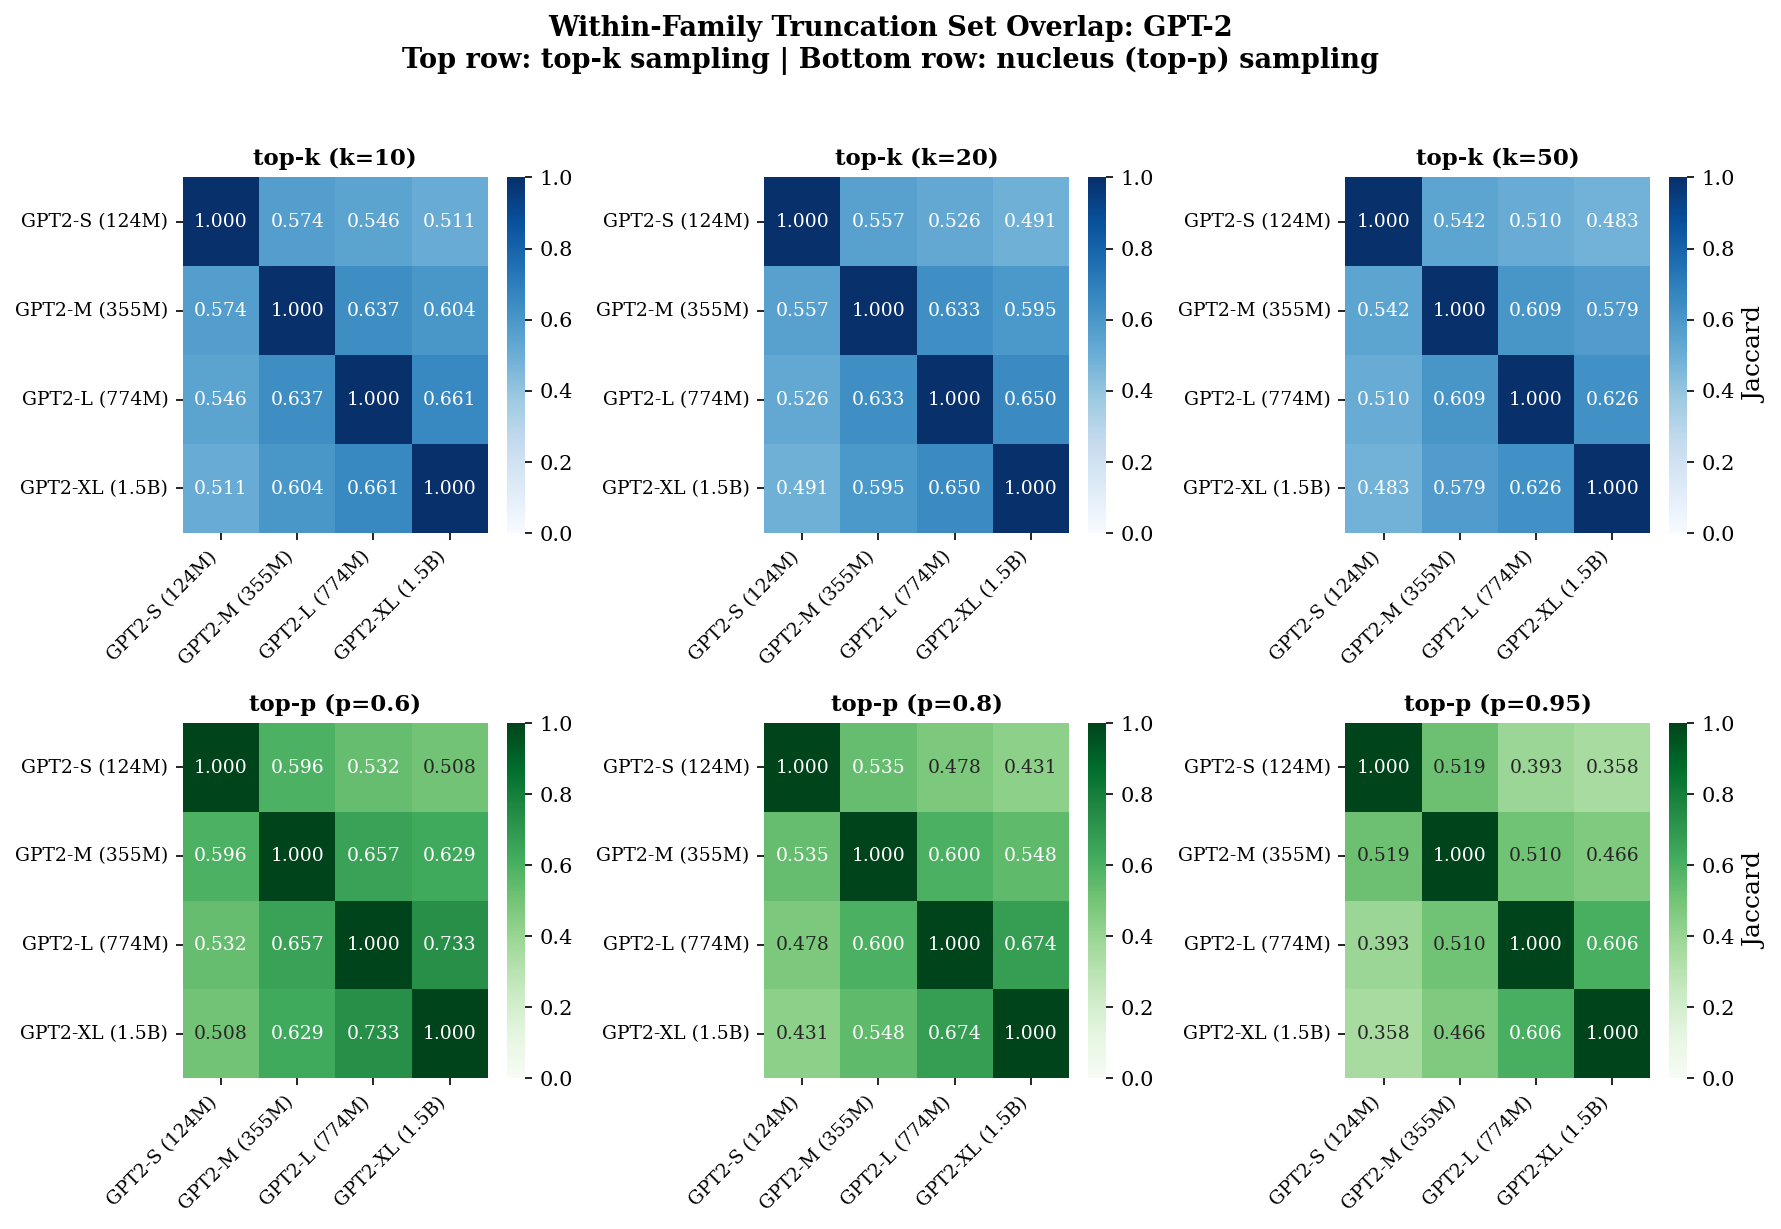


TOP-K OVERLAP SUMMARY: GPT-2
k                                  10     20     50
Model A        Model B                             
GPT2-L\n(774M) GPT2-XL\n(1.5B)  0.661  0.650  0.626
GPT2-M\n(355M) GPT2-L\n(774M)   0.637  0.633  0.609
               GPT2-XL\n(1.5B)  0.604  0.595  0.579
GPT2-S\n(124M) GPT2-L\n(774M)   0.546  0.526  0.510
               GPT2-M\n(355M)   0.574  0.557  0.542
               GPT2-XL\n(1.5B)  0.511  0.491  0.483

TOP-P OVERLAP SUMMARY: GPT-2
p                                0.60   0.80   0.95
Model A        Model B                             
GPT2-L\n(774M) GPT2-XL\n(1.5B)  0.733  0.674  0.606
GPT2-M\n(355M) GPT2-L\n(774M)   0.657  0.600  0.510
               GPT2-XL\n(1.5B)  0.629  0.548  0.466
GPT2-S\n(124M) GPT2-L\n(774M)   0.532  0.478  0.393
               GPT2-M\n(355M)   0.596  0.535  0.519
               GPT2-XL\n(1.5B)  0.508  0.431  0.358


In [ ]:
print("\n" + "="*70)
print("GPT-2 FAMILY ANALYSIS")
print("="*70)

df_gpt2_topk, df_gpt2_topp = compute_family_overlap_topk_and_topp(
    family=GPT2_FAMILY,
    texts=SAMPLE_TEXTS,
    k_values=[10, 20, 50],
    p_values=[0.6, 0.8, 0.95],
    family_name="GPT2"
)

plot_family_overlap_combined(
    df_gpt2_topk, df_gpt2_topp,
    "GPT-2",
    "gpt2_family_overlap.pdf"
)

### Qwen2 Family Analysis


QWEN2 FAMILY ANALYSIS

Loading Qwen2 (0.5B)...


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

  Processing wikinews...
  Processing wikipedia...
  Processing bookcorpus...
  Done. Memory cleared.

Loading Qwen2 (7B)...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

  Processing wikinews...
  Processing wikipedia...
  Processing bookcorpus...
  Done. Memory cleared.

Computing pairwise overlaps...
  Qwen2 (0.5B) vs Qwen2 (1.5B)
  Qwen2 (0.5B) vs Qwen2 (7B)
  Qwen2 (1.5B) vs Qwen2 (7B)

Saved: qwen2_topk_overlap.csv, qwen2_topp_overlap.csv
Saved: qwen2_family_overlap.pdf


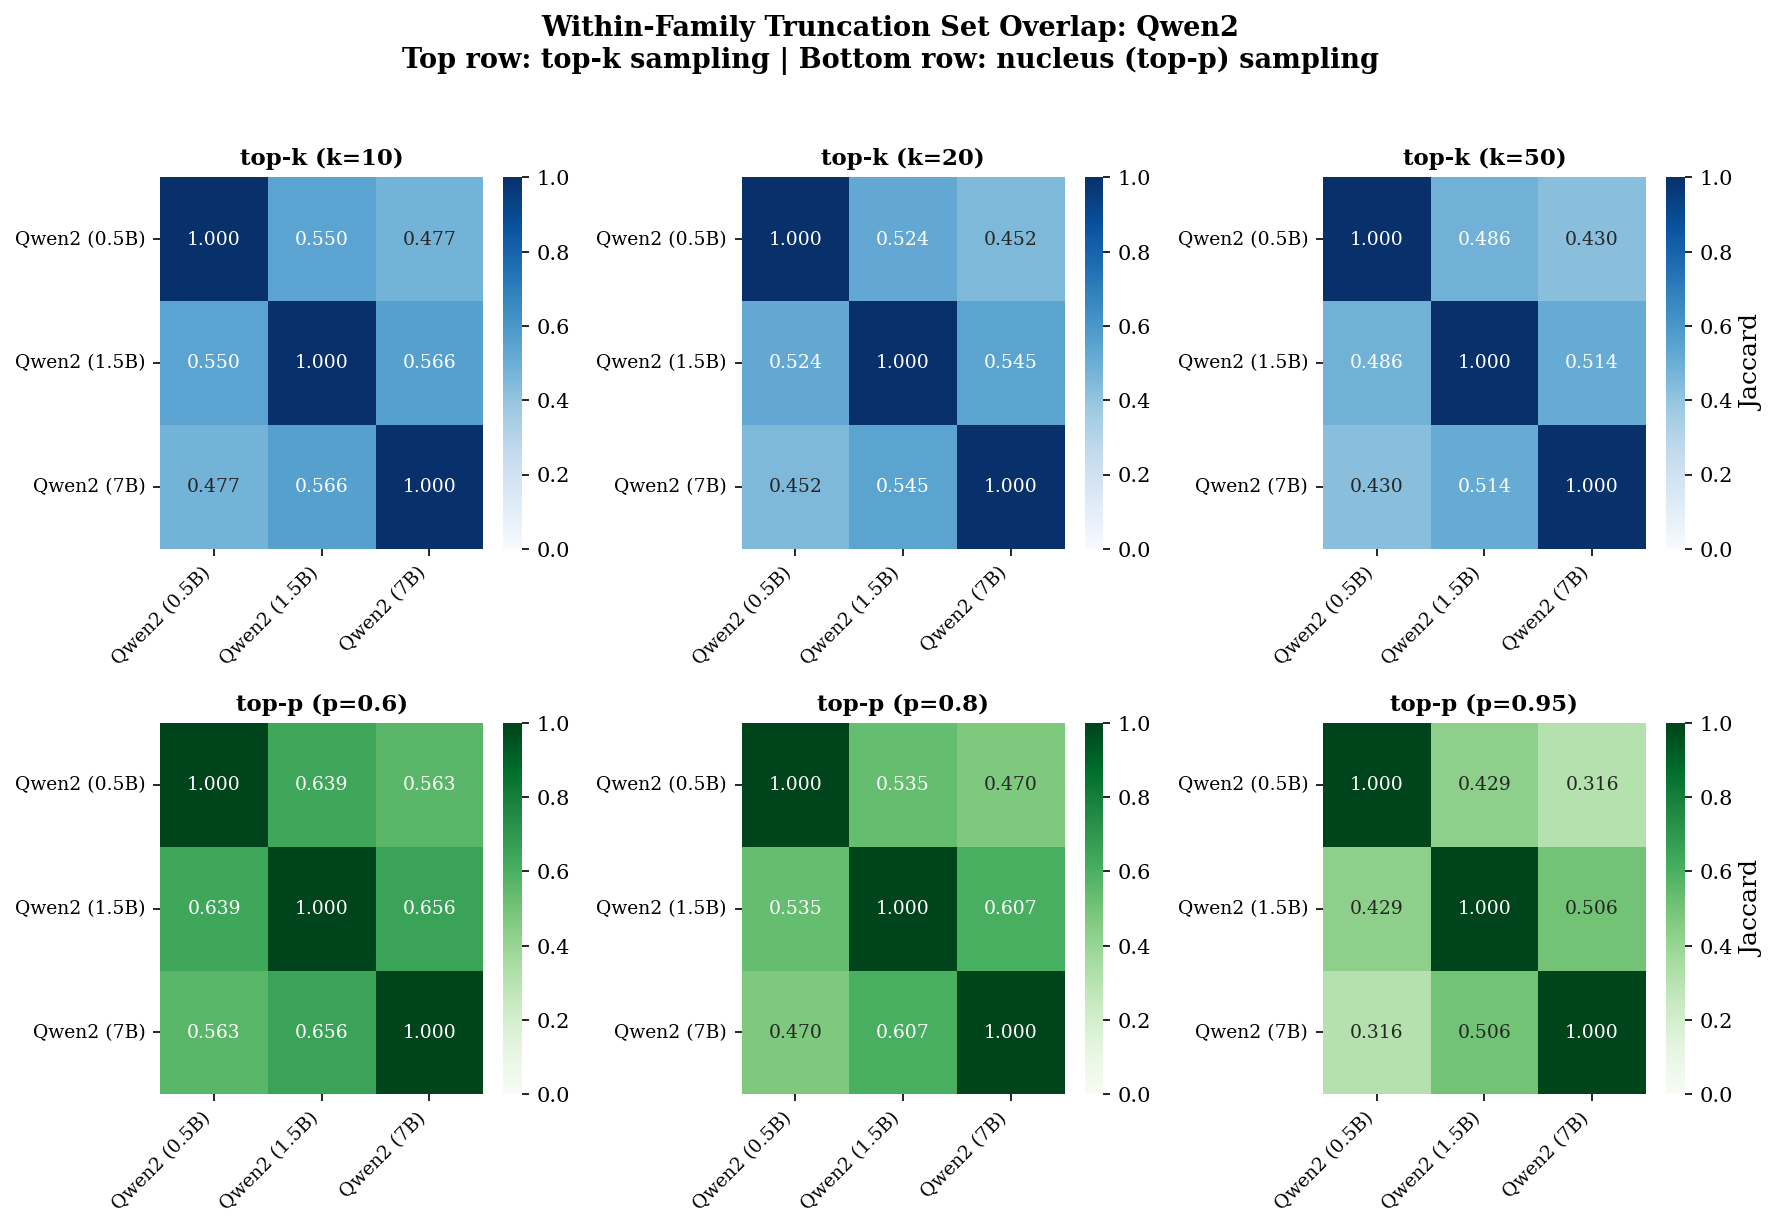


TOP-K OVERLAP SUMMARY: Qwen2
k                               10     20     50
Model A       Model B                           
Qwen2\n(0.5B) Qwen2\n(1.5B)  0.550  0.524  0.486
              Qwen2\n(7B)    0.477  0.452  0.430
Qwen2\n(1.5B) Qwen2\n(7B)    0.566  0.545  0.514

TOP-P OVERLAP SUMMARY: Qwen2
p                             0.60   0.80   0.95
Model A       Model B                           
Qwen2\n(0.5B) Qwen2\n(1.5B)  0.639  0.535  0.429
              Qwen2\n(7B)    0.563  0.470  0.316
Qwen2\n(1.5B) Qwen2\n(7B)    0.656  0.607  0.506


In [ ]:
print("\n" + "="*70)
print("QWEN2 FAMILY ANALYSIS")
print("="*70)

df_qwen2_topk, df_qwen2_topp = compute_family_overlap_topk_and_topp(
    family=QWEN2_FAMILY,
    texts=SAMPLE_TEXTS,
    k_values=[10, 20, 50],
    p_values=[0.6, 0.8, 0.95],
    family_name="Qwen2"
)

plot_family_overlap_combined(
    df_qwen2_topk, df_qwen2_topp,
    "Qwen2",
    "qwen2_family_overlap.pdf"
)

---
# Part 3: Generate LaTeX Tables

In [ ]:
def generate_latex_tables(df_gpt2_topk, df_gpt2_topp, df_qwen2_topk, df_qwen2_topp):
    """
    Generate LaTeX tables for the paper.
    """

    # Helper to clean model names for LaTeX
    def clean_name(name):
        return name.replace('\n', ' ').replace('(', '').replace(')', '').replace(' ', '-')

    def short_name(name):
        # Extract just the size part
        parts = name.replace('\n', ' ').split()
        if len(parts) >= 2:
            return f"{parts[0]}-{parts[1].replace('(','').replace(')','')}"
        return name.replace('\n', '-')

    print("\n" + "="*80)
    print("LATEX TABLE: Within-Family Top-k Overlap")
    print("="*80)

    latex_topk = r"""
\begin{table}[t]
\centering
\small
\begin{tabular}{llccc}
\toprule
\textbf{Family} & \textbf{Model Pair} & $k=10$ & $k=20$ & $k=50$ \\
\midrule
"""

    # GPT-2 rows
    for (ma, mb), group in df_gpt2_topk.groupby(['Model A', 'Model B']):
        row_data = group.groupby('k')['Overlap'].mean()
        latex_topk += f"GPT-2 & {short_name(ma)}--{short_name(mb)} & "
        latex_topk += f"{row_data.get(10, 0):.3f} & {row_data.get(20, 0):.3f} & {row_data.get(50, 0):.3f} \\\\\n"

    latex_topk += r"\midrule" + "\n"

    # Qwen2 rows
    for (ma, mb), group in df_qwen2_topk.groupby(['Model A', 'Model B']):
        row_data = group.groupby('k')['Overlap'].mean()
        latex_topk += f"Qwen2 & {short_name(ma)}--{short_name(mb)} & "
        latex_topk += f"{row_data.get(10, 0):.3f} & {row_data.get(20, 0):.3f} & {row_data.get(50, 0):.3f} \\\\\n"

    latex_topk += r"""
\bottomrule
\end{tabular}
\caption{Within-family top-$k$ truncation set overlap (Jaccard coefficient).
Values represent the average overlap across three text domains.}
\label{tab:within_family_topk}
\end{table}
"""
    print(latex_topk)

    print("\n" + "="*80)
    print("LATEX TABLE: Within-Family Top-p Overlap")
    print("="*80)

    latex_topp = r"""
\begin{table}[t]
\centering
\small
\begin{tabular}{llccc}
\toprule
\textbf{Family} & \textbf{Model Pair} & $p=0.6$ & $p=0.8$ & $p=0.95$ \\
\midrule
"""

    # GPT-2 rows
    for (ma, mb), group in df_gpt2_topp.groupby(['Model A', 'Model B']):
        row_data = group.groupby('p')['Overlap'].mean()
        latex_topp += f"GPT-2 & {short_name(ma)}--{short_name(mb)} & "
        latex_topp += f"{row_data.get(0.6, 0):.3f} & {row_data.get(0.8, 0):.3f} & {row_data.get(0.95, 0):.3f} \\\\\n"

    latex_topp += r"\midrule" + "\n"

    # Qwen2 rows
    for (ma, mb), group in df_qwen2_topp.groupby(['Model A', 'Model B']):
        row_data = group.groupby('p')['Overlap'].mean()
        latex_topp += f"Qwen2 & {short_name(ma)}--{short_name(mb)} & "
        latex_topp += f"{row_data.get(0.6, 0):.3f} & {row_data.get(0.8, 0):.3f} & {row_data.get(0.95, 0):.3f} \\\\\n"

    latex_topp += r"""
\bottomrule
\end{tabular}
\caption{Within-family nucleus (top-$p$) truncation set overlap (Jaccard coefficient).
Values represent the average overlap across three text domains.}
\label{tab:within_family_topp}
\end{table}
"""
    print(latex_topp)

    # Save to files
    with open("table_within_family_topk.tex", "w") as f:
        f.write(latex_topk)
    with open("table_within_family_topp.tex", "w") as f:
        f.write(latex_topp)
    print("\nSaved: table_within_family_topk.tex, table_within_family_topp.tex")

# Run after both family analyses complete
# generate_latex_tables(df_gpt2_topk, df_gpt2_topp, df_qwen2_topk, df_qwen2_topp)

---
# Part 4: Analysis Template

**Fill in the [PLACEHOLDER] values with actual results after running the experiments.**

In [ ]:
def generate_analysis_template(motivation_results, df_gpt2_topk, df_gpt2_topp, df_qwen2_topk, df_qwen2_topp):
    """
    Generate a concise analysis based on the actual results.
    Only uses values from the data - no assumptions.
    """

    print("\n" + "="*80)
    print("ANALYSIS FOR PAPER (based on experimental results)")
    print("="*80)

    # Motivation figure statistics
    print("\n### MOTIVATION FIGURE RESULTS ###\n")

    for model_name, data in motivation_results.items():
        ranks = data['ranks']
        print(f"{model_name}:")
        print(f"  - Total tokens analyzed: {len(ranks)}")
        print(f"  - Median rank: {np.median(ranks):.1f}")
        print(f"  - Mean rank: {np.mean(ranks):.1f}")
        for k in [5, 10, 20, 50]:
            excl = 100 * (1 - compute_human_token_in_topk(ranks, k))
            print(f"  - Exclusion rate at k={k}: {excl:.1f}%")
        print()

    # Within-family overlap statistics
    print("\n### WITHIN-FAMILY OVERLAP RESULTS ###\n")

    print("GPT-2 Family (top-k):")
    for k in sorted(df_gpt2_topk['k'].unique()):
        mean_overlap = df_gpt2_topk[df_gpt2_topk['k'] == k]['Overlap'].mean()
        std_overlap = df_gpt2_topk[df_gpt2_topk['k'] == k]['Overlap'].std()
        print(f"  k={k}: mean overlap = {mean_overlap:.3f} ± {std_overlap:.3f}")

    print("\nGPT-2 Family (top-p):")
    for p in sorted(df_gpt2_topp['p'].unique()):
        mean_overlap = df_gpt2_topp[df_gpt2_topp['p'] == p]['Overlap'].mean()
        std_overlap = df_gpt2_topp[df_gpt2_topp['p'] == p]['Overlap'].std()
        print(f"  p={p}: mean overlap = {mean_overlap:.3f} ± {std_overlap:.3f}")

    print("\nQwen2 Family (top-k):")
    for k in sorted(df_qwen2_topk['k'].unique()):
        mean_overlap = df_qwen2_topk[df_qwen2_topk['k'] == k]['Overlap'].mean()
        std_overlap = df_qwen2_topk[df_qwen2_topk['k'] == k]['Overlap'].std()
        print(f"  k={k}: mean overlap = {mean_overlap:.3f} ± {std_overlap:.3f}")

    print("\nQwen2 Family (top-p):")
    for p in sorted(df_qwen2_topp['p'].unique()):
        mean_overlap = df_qwen2_topp[df_qwen2_topp['p'] == p]['Overlap'].mean()
        std_overlap = df_qwen2_topp[df_qwen2_topp['p'] == p]['Overlap'].std()
        print(f"  p={p}: mean overlap = {mean_overlap:.3f} ± {std_overlap:.3f}")

    # Cross-family comparison
    print("\n### CROSS-FAMILY COMPARISON ###\n")

    gpt2_mean_k10 = df_gpt2_topk[df_gpt2_topk['k'] == 10]['Overlap'].mean()
    qwen2_mean_k10 = df_qwen2_topk[df_qwen2_topk['k'] == 10]['Overlap'].mean()
    print(f"At k=10: GPT-2 family mean overlap = {gpt2_mean_k10:.3f}, Qwen2 family = {qwen2_mean_k10:.3f}")

    gpt2_mean_p09 = df_gpt2_topp[df_gpt2_topp['p'] == 0.95]['Overlap'].mean()
    qwen2_mean_p09 = df_qwen2_topp[df_qwen2_topp['p'] == 0.95]['Overlap'].mean()
    print(f"At p=0.95: GPT-2 family mean overlap = {gpt2_mean_p09:.3f}, Qwen2 family = {qwen2_mean_p09:.3f}")

    print("\n" + "="*80)
    print("END OF ANALYSIS")
    print("="*80)

# Run after all experiments complete
# generate_analysis_template(motivation_results, df_gpt2_topk, df_gpt2_topp, df_qwen2_topk, df_qwen2_topp)

---
# Quick Test

In [ ]:
def quick_test():
    """Quick test with smallest model to verify setup."""
    print("Running quick test...")

    tokenizer = AutoTokenizer.from_pretrained("gpt2")
    model = AutoModelForCausalLM.from_pretrained("gpt2").to(device)
    model.eval()

    text = MOTIVATION_TEXT[:200]

    # Test rank computation
    ranks, tokens, _ = get_token_ranks(model, tokenizer, text)
    print(f"✓ Ranks: {len(ranks)} tokens, median={np.median(ranks):.1f}")

    # Test top-k sets
    topk = get_topk_set(model, tokenizer, text, k=10)
    print(f"✓ Top-k: {len(topk)} positions, avg set size={np.mean([len(s) for s in topk]):.1f}")

    # Test top-p sets
    topp = get_topp_set(model, tokenizer, text, p=0.9)
    print(f"✓ Top-p: {len(topp)} positions, avg set size={np.mean([len(s) for s in topp]):.1f}")

    del model
    torch.cuda.empty_cache()
    print("\n✓ All tests PASSED!")

quick_test()

Running quick test...
✓ Ranks: 30 tokens, median=1.0
✓ Top-k: 30 positions, avg set size=10.0
✓ Top-p: 30 positions, avg set size=631.1

✓ All tests PASSED!


---
# Run Full Pipeline


################################################################################
# FULL ANALYSIS PIPELINE
################################################################################

[1/4] Creating Motivation Figure...

Processing: GPT2-XL (1.5B)
Computed ranks for 91 tokens

Processing: Qwen2-7B


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Computed ranks for 92 tokens

Saved: motivation_figure.pdf


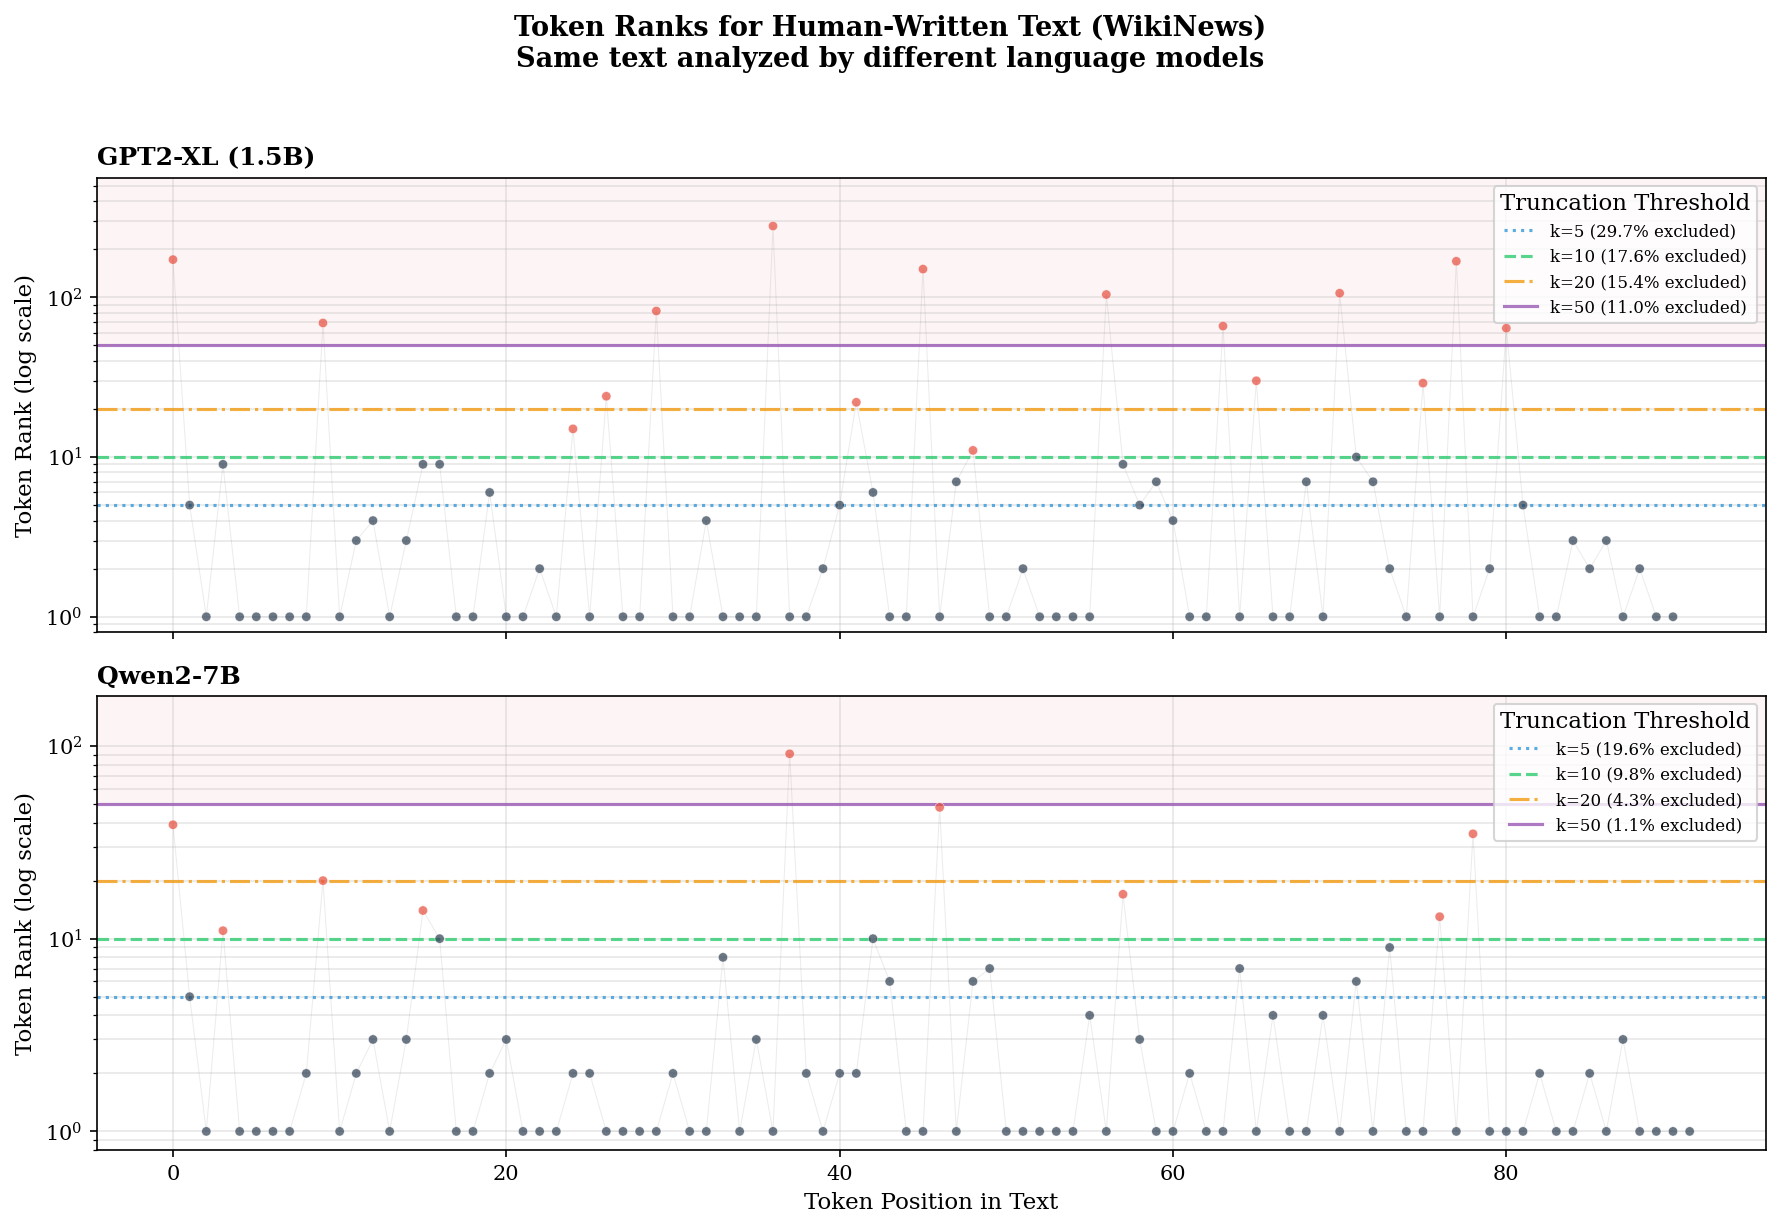


COMPARATIVE STATISTICS
Model                       Median     Mean      Max  k=5:excl  k=10:excl  k=20:excl  k=50:excl  
----------------------------------------------------------------------
GPT2-XL (1.5B)                 1.0     17.4      279     29.7%     17.6%     15.4%     11.0%  
Qwen2-7B                       1.0      5.1       91     19.6%      9.8%      4.3%      1.1%  

[2/4] Analyzing GPT-2 Family...

Loading GPT2-S (124M)...
  Processing wikinews...
  Processing wikipedia...
  Processing bookcorpus...
  Done. Memory cleared.

Loading GPT2-M (355M)...
  Processing wikinews...
  Processing wikipedia...
  Processing bookcorpus...
  Done. Memory cleared.

Loading GPT2-L (774M)...
  Processing wikinews...
  Processing wikipedia...
  Processing bookcorpus...
  Done. Memory cleared.

Loading GPT2-XL (1.5B)...
  Processing wikinews...
  Processing wikipedia...
  Processing bookcorpus...
  Done. Memory cleared.

Computing pairwise overlaps...
  GPT2-S (124M) vs GPT2-M (355M)
  GPT2

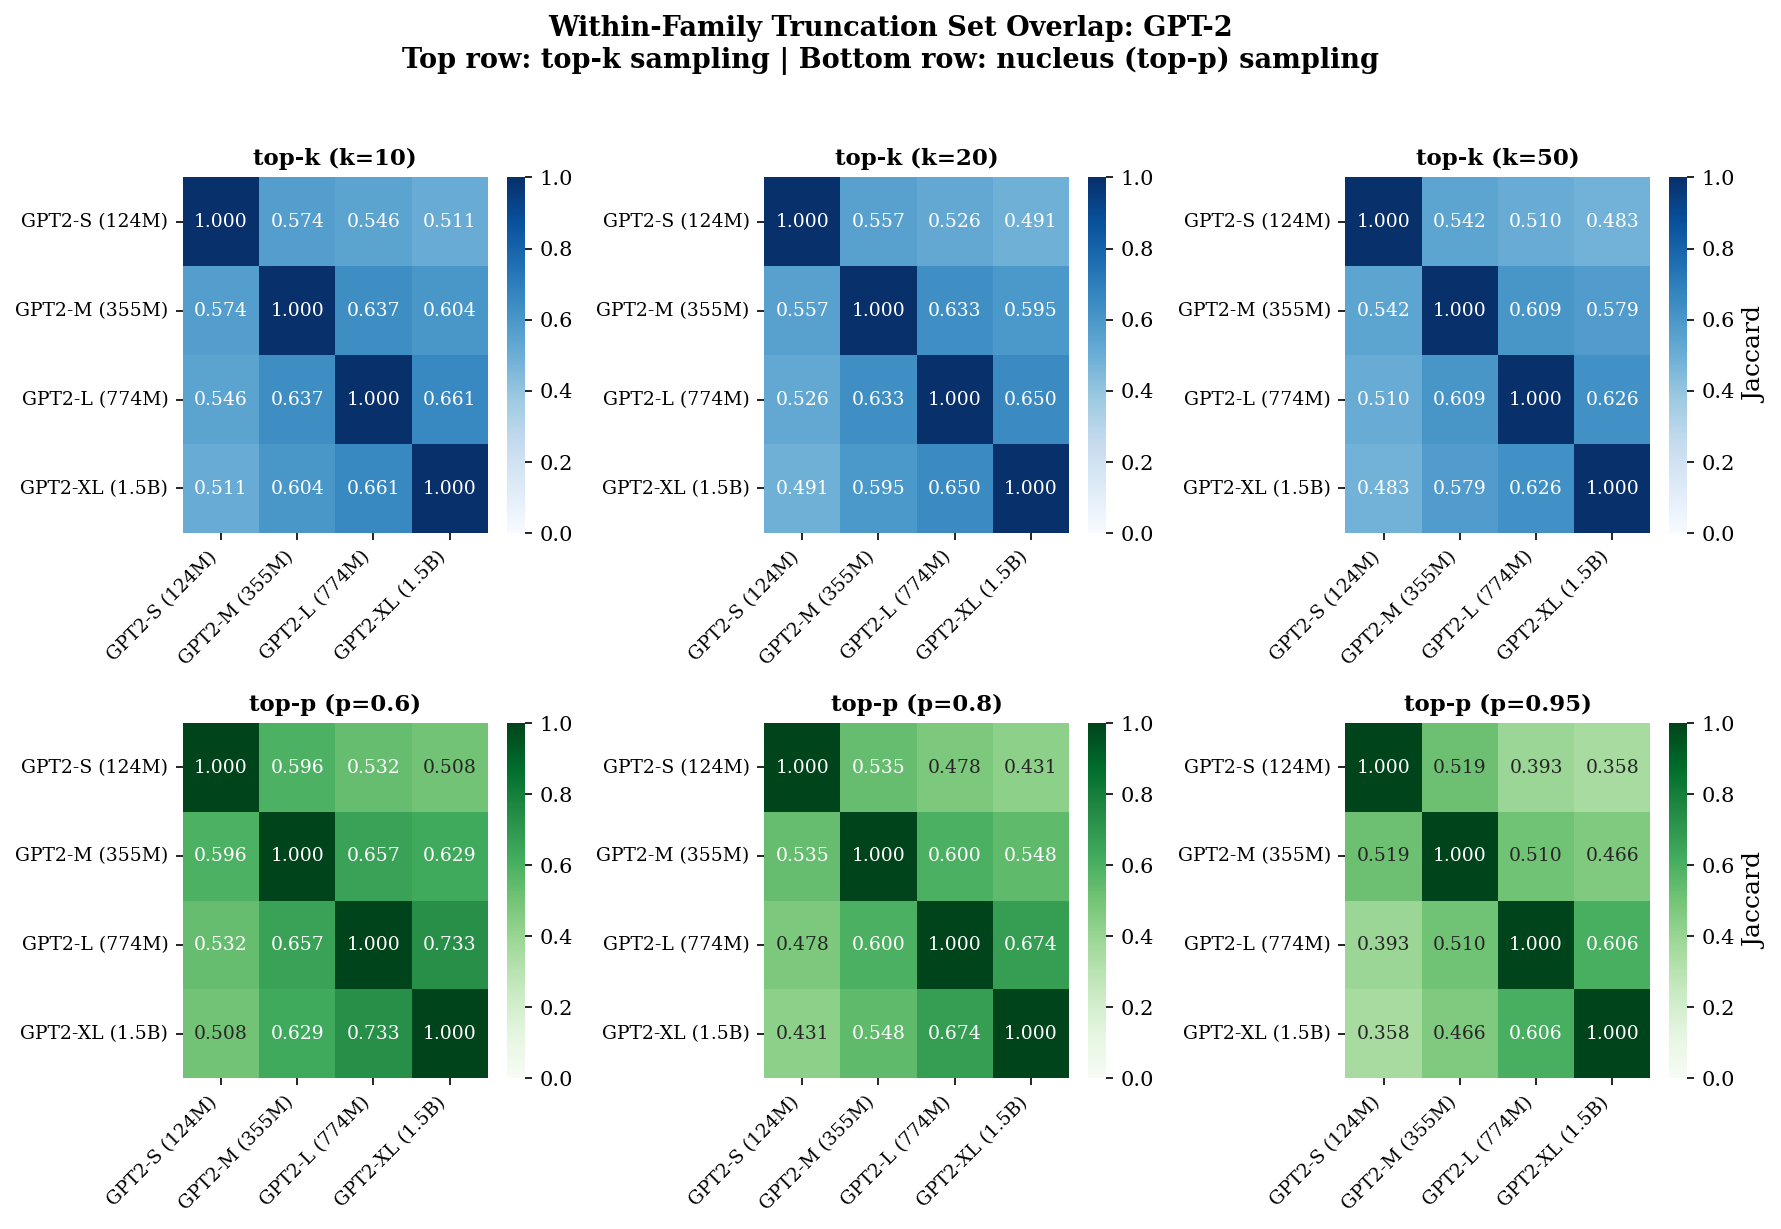


TOP-K OVERLAP SUMMARY: GPT-2
k                                  10     20     50
Model A        Model B                             
GPT2-L\n(774M) GPT2-XL\n(1.5B)  0.661  0.650  0.626
GPT2-M\n(355M) GPT2-L\n(774M)   0.637  0.633  0.609
               GPT2-XL\n(1.5B)  0.604  0.595  0.579
GPT2-S\n(124M) GPT2-L\n(774M)   0.546  0.526  0.510
               GPT2-M\n(355M)   0.574  0.557  0.542
               GPT2-XL\n(1.5B)  0.511  0.491  0.483

TOP-P OVERLAP SUMMARY: GPT-2
p                                0.60   0.80   0.95
Model A        Model B                             
GPT2-L\n(774M) GPT2-XL\n(1.5B)  0.733  0.674  0.606
GPT2-M\n(355M) GPT2-L\n(774M)   0.657  0.600  0.510
               GPT2-XL\n(1.5B)  0.629  0.548  0.466
GPT2-S\n(124M) GPT2-L\n(774M)   0.532  0.478  0.393
               GPT2-M\n(355M)   0.596  0.535  0.519
               GPT2-XL\n(1.5B)  0.508  0.431  0.358

[3/4] Analyzing Qwen2 Family...

Loading Qwen2 (0.5B)...
  Processing wikinews...
  Processing wikipedia...

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

  Processing wikinews...
  Processing wikipedia...
  Processing bookcorpus...
  Done. Memory cleared.

Computing pairwise overlaps...
  Qwen2 (0.5B) vs Qwen2 (1.5B)
  Qwen2 (0.5B) vs Qwen2 (7B)
  Qwen2 (1.5B) vs Qwen2 (7B)

Saved: qwen2_topk_overlap.csv, qwen2_topp_overlap.csv
Saved: qwen2_family_overlap.pdf


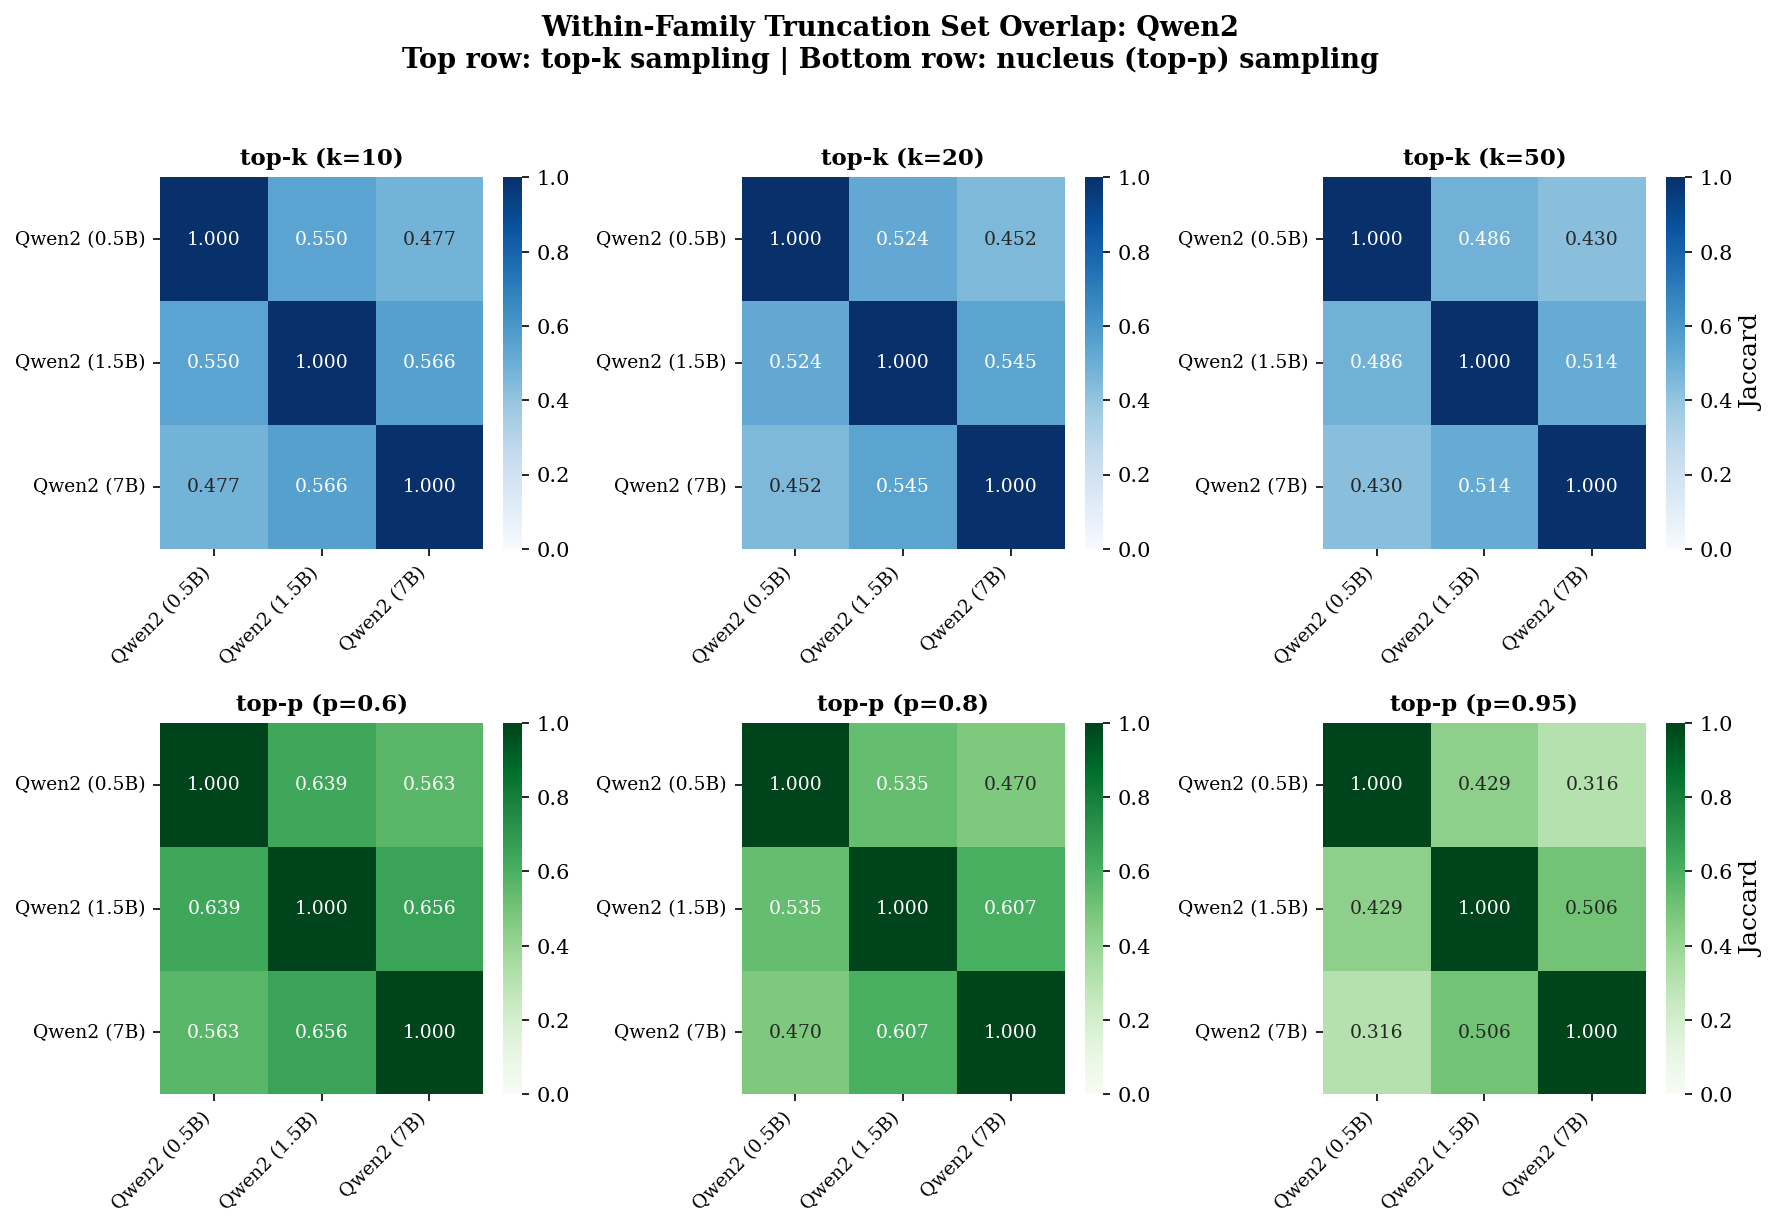


TOP-K OVERLAP SUMMARY: Qwen2
k                               10     20     50
Model A       Model B                           
Qwen2\n(0.5B) Qwen2\n(1.5B)  0.550  0.524  0.486
              Qwen2\n(7B)    0.477  0.452  0.430
Qwen2\n(1.5B) Qwen2\n(7B)    0.566  0.545  0.514

TOP-P OVERLAP SUMMARY: Qwen2
p                             0.60   0.80   0.95
Model A       Model B                           
Qwen2\n(0.5B) Qwen2\n(1.5B)  0.639  0.535  0.429
              Qwen2\n(7B)    0.563  0.470  0.316
Qwen2\n(1.5B) Qwen2\n(7B)    0.656  0.607  0.506

[4/4] Generating LaTeX tables and analysis...

LATEX TABLE: Within-Family Top-k Overlap

\begin{table}[t]
\centering
\small
\begin{tabular}{llccc}
\toprule
\textbf{Family} & \textbf{Model Pair} & $k=10$ & $k=20$ & $k=50$ \\
\midrule
GPT-2 & GPT2-L-774M--GPT2-XL-1.5B & 0.661 & 0.650 & 0.626 \\
GPT-2 & GPT2-M-355M--GPT2-L-774M & 0.637 & 0.633 & 0.609 \\
GPT-2 & GPT2-M-355M--GPT2-XL-1.5B & 0.604 & 0.595 & 0.579 \\
GPT-2 & GPT2-S-124M--GPT2-L-774M &

In [ ]:
def run_full_pipeline():
    """
    Run the complete analysis pipeline.
    """
    print("\n" + "#"*80)
    print("# FULL ANALYSIS PIPELINE")
    print("#"*80)

    # 1. Motivation Figure
    print("\n[1/4] Creating Motivation Figure...")
    motivation_results = create_motivation_figure_two_models(
        text=MOTIVATION_TEXT,
        text_source=MOTIVATION_TEXT_SOURCE,
        model_configs=MOTIVATION_MODELS,
        k_values=[5, 10, 20, 50],
        save_path="motivation_figure.pdf"
    )

    # 2. GPT-2 Family
    print("\n[2/4] Analyzing GPT-2 Family...")
    df_gpt2_topk, df_gpt2_topp = compute_family_overlap_topk_and_topp(
        family=GPT2_FAMILY,
        texts=SAMPLE_TEXTS,
        k_values=[10, 20, 50],
        p_values=[0.6, 0.8, 0.95],
        family_name="GPT2"
    )
    plot_family_overlap_combined(df_gpt2_topk, df_gpt2_topp, "GPT-2", "gpt2_family_overlap.pdf")

    # 3. Qwen2 Family
    print("\n[3/4] Analyzing Qwen2 Family...")
    df_qwen2_topk, df_qwen2_topp = compute_family_overlap_topk_and_topp(
        family=QWEN2_FAMILY,
        texts=SAMPLE_TEXTS,
        k_values=[10, 20, 50],
        p_values=[0.6, 0.8, 0.95],
        family_name="Qwen2"
    )
    plot_family_overlap_combined(df_qwen2_topk, df_qwen2_topp, "Qwen2", "qwen2_family_overlap.pdf")

    # 4. Generate outputs
    print("\n[4/4] Generating LaTeX tables and analysis...")
    generate_latex_tables(df_gpt2_topk, df_gpt2_topp, df_qwen2_topk, df_qwen2_topp)
    generate_analysis_template(motivation_results, df_gpt2_topk, df_gpt2_topp, df_qwen2_topk, df_qwen2_topp)

    print("\n" + "#"*80)
    print("# PIPELINE COMPLETE")
    print("#"*80)
    print("\nGenerated files:")
    print("  - motivation_figure.pdf/.png")
    print("  - gpt2_family_overlap.pdf/.png")
    print("  - qwen2_family_overlap.pdf/.png")
    print("  - gpt2_topk_overlap.csv, gpt2_topp_overlap.csv")
    print("  - qwen2_topk_overlap.csv, qwen2_topp_overlap.csv")
    print("  - table_within_family_topk.tex, table_within_family_topp.tex")

    return {
        'motivation': motivation_results,
        'gpt2_topk': df_gpt2_topk,
        'gpt2_topp': df_gpt2_topp,
        'qwen2_topk': df_qwen2_topk,
        'qwen2_topp': df_qwen2_topp
    }

# Uncomment to run:
results = run_full_pipeline()